In [1]:
TRAIN = '/kaggle/input/datasets/gb17av/7-cat-species-image-dataset/Cats7/dataset'

We want to use ResNeXt image embeddings for an exploratory plot and for classification, so let's add some code to get those for us.

In [2]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np


DEVICE = torch.device('cpu')
OUTPUT_SIZE = 2048

model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V2)

extraction_layer = model._modules.get('avgpool')
model.to(DEVICE)
model.eval()

scaler = transforms.Resize((224, 224))
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.ToTensor()

def get_vec(arg, model, extraction_layer):
    image = normalize(to_tensor(scaler(arg))).unsqueeze(0).to(DEVICE)
    result = torch.zeros(1, OUTPUT_SIZE, 1, 1)
    def copy_data(m, i, o):
        result.copy_(o.data)
    hooked = extraction_layer.register_forward_hook(copy_data)
    with torch.no_grad():
        model(image)
    hooked.remove()
    return result

Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 152MB/s]


Let's load up all of our data. We don't have a lot, so this will just take a couple of minutes.

In [3]:
import arrow
import base64
import pandas as pd
import tqdm

from glob import iglob
from io import BytesIO
from os.path import basename
from os.path import isdir
from PIL import Image


N = 2000
THUMBNAIL_SIZE = (48, 48)

def embed(model, filename: str):
    with Image.open(fp=filename, mode='r') as image:
        return get_vec(arg=image.convert('RGB'), model=model, extraction_layer=extraction_layer).numpy().reshape(OUTPUT_SIZE,)


# https://stackoverflow.com/a/952952
def flatten(arg):
    return [x for xs in arg for x in xs]

def png(filename: str) -> str:
    with Image.open(fp=filename, mode='r') as image:
        buffer = BytesIO()
        # our images are pretty big; let's shrink the hover images to thumbnail size
        image.resize(size=THUMBNAIL_SIZE).convert('RGBA').save(buffer, format='png')
        return 'data:image/png;base64,' + base64.b64encode(buffer.getvalue()).decode()

def get_picture_from_glob(arg: str, tag: str,) -> list:
    time_get = arrow.now()
    result = [pd.Series(data=[tag, basename(input_file), embed(model=model, filename=input_file), png(filename=input_file)],
                        index=['tag', 'name', 'value', 'png'] )
        for index, input_file in enumerate(tqdm.tqdm(list(iglob(pathname=arg))[:N])) ]
    print('encoded {} rows of {}  in {}'.format(len(result), tag, arrow.now() - time_get))
    return result

time_start = arrow.now()
train_dict = {basename(folder) : folder + '/*.*' for folder in iglob(TRAIN + '/*') if isdir(folder) }
train_df = pd.DataFrame(data=flatten(arg=[get_picture_from_glob(arg=value, tag=key) for key, value in train_dict.items()]))
train_df['tag'] = train_df['tag'].str.replace('-', ' ')
print('done in {}'.format(arrow.now() - time_start))

100%|██████████| 150/150 [00:22<00:00,  6.69it/s]


encoded 150 rows of panthera-onca  in 0:00:22.432755


100%|██████████| 150/150 [00:22<00:00,  6.81it/s]


encoded 150 rows of puma-concolor  in 0:00:22.059692


100%|██████████| 150/150 [00:21<00:00,  6.84it/s]


...

encoded 150 rows of panthera-leo  in 0:00:22.274609


100%|██████████| 150/150 [00:22<00:00,  6.81it/s]


encoded 150 rows of acinonyx-jubatus  in 0:00:22.041947


100%|██████████| 150/150 [00:22<00:00,  6.73it/s]


encoded 150 rows of panthera-pardus  in 0:00:22.297795
done in 0:02:35.417276


We already know our classes are balanced, so visualizing the class balance with a pie chart is okay. Just this once.

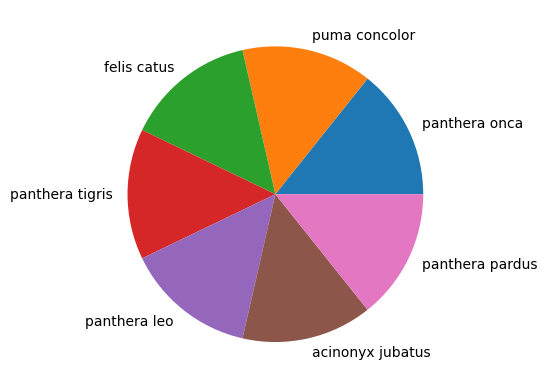

In [4]:
import matplotlib.pyplot as plt

train_df['tag'].value_counts(normalize=False).to_frame().plot.pie(y='count')
plt.ylabel('')
plt.legend().remove()
plt.show()

Let's use TSNE to add x/y coordinates based on our image embeddings.

In [5]:
from sklearn.manifold import TSNE

train_reducer = TSNE(random_state=2026, verbose=True, n_jobs=1, perplexity=20.0, init='pca')
train_df[['x', 'y']] = train_reducer.fit_transform(X=train_df['value'].apply(func=pd.Series))

[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 1050 samples in 0.006s...
[t-SNE] Computed neighbors for 1050 samples in 0.225s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1050
[t-SNE] Computed conditional probabilities for sample 1050 / 1050
[t-SNE] Mean sigma: 1.702089
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.393147
[t-SNE] KL divergence after 1000 iterations: 0.859521


Let's make a static plot of all of our images. This is probably a cooler concept than a reality, for reasons that will soon be clear.

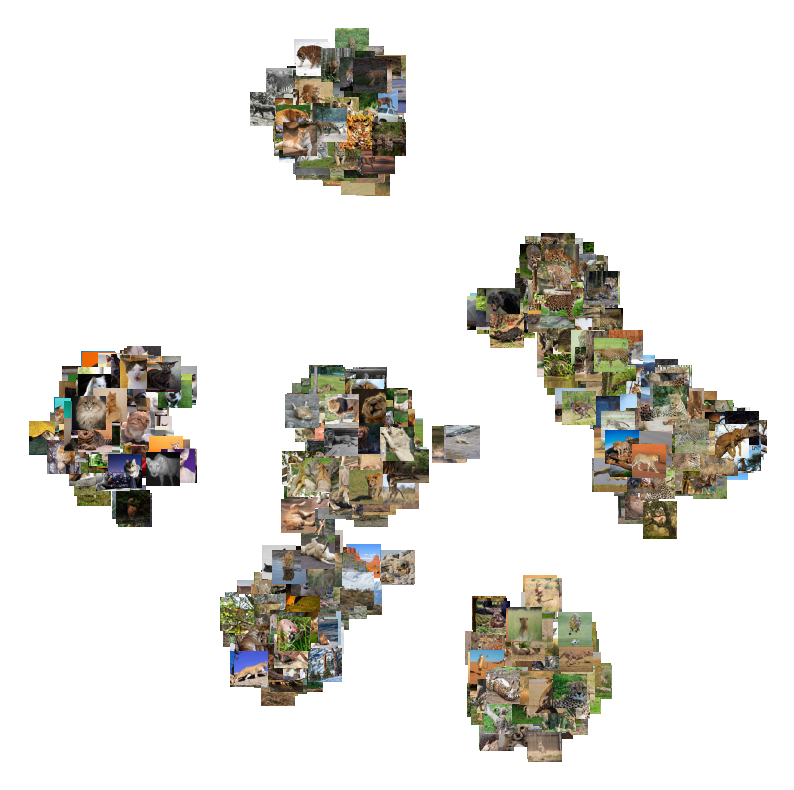

In [6]:
import base64
import io
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from PIL import Image

# we recycled some PNG encoding code above, and we need to postprocess it for using with matplotlib
train_df['PNG'] = train_df['png'].str.replace('^data:image/png;base64,', '', regex=True)

fig, ax = plt.subplots(figsize=(10, 10))

for index, row in train_df.iterrows():
    img_bytes = base64.b64decode(row["PNG"])
    img = Image.open(io.BytesIO(img_bytes))
    imagebox = OffsetImage(img, zoom=0.5)
    ab = AnnotationBbox(imagebox, (row["x"], row["y"]), frameon=False, pad=0)
    ax.add_artist(ab)
ax.scatter(train_df["x"], train_df["y"], alpha=0)
ax.axis('off')
plt.show()

What does this plot tell us? It tells us that images in the same class are very similar from a ResNeXt/TSNE perspective, with some edge cases. Unfortunately, we can't tell much about any particular image.

Let's build a model and see what we get.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(train_df['value'].apply(pd.Series), train_df['tag'], test_size=0.25, random_state=2026, stratify=train_df['tag'])
logreg = LogisticRegression(max_iter=10000, tol=1e-12).fit(X_train, y_train)
print('model fit in {} iterations'.format(logreg.n_iter_[0]))
print('accuracy: {:5.4f}'.format(accuracy_score(y_true=y_test, y_pred=logreg.predict(X=X_test))))
print('f1: {:5.4f}'.format(f1_score(average='weighted', y_true=y_test, y_pred=logreg.predict(X=X_test))))
print(classification_report(y_true=y_test, y_pred=logreg.predict(X=X_test), zero_division=0.0))

model fit in 272 iterations
accuracy: 0.9772
f1: 0.9771
                  precision    recall  f1-score   support

acinonyx jubatus       0.97      1.00      0.99        38
     felis catus       1.00      1.00      1.00        38
    panthera leo       1.00      0.95      0.97        38
   panthera onca       0.97      0.95      0.96        37
 panthera pardus       0.95      0.95      0.95        37
 panthera tigris       1.00      1.00      1.00        37
   puma concolor       0.95      1.00      0.97        38

        accuracy                           0.98       263
       macro avg       0.98      0.98      0.98       263
    weighted avg       0.98      0.98      0.98       263



Given what our scatter plot showed us above, this isn't surprising at all. What do our model probabilities look like?

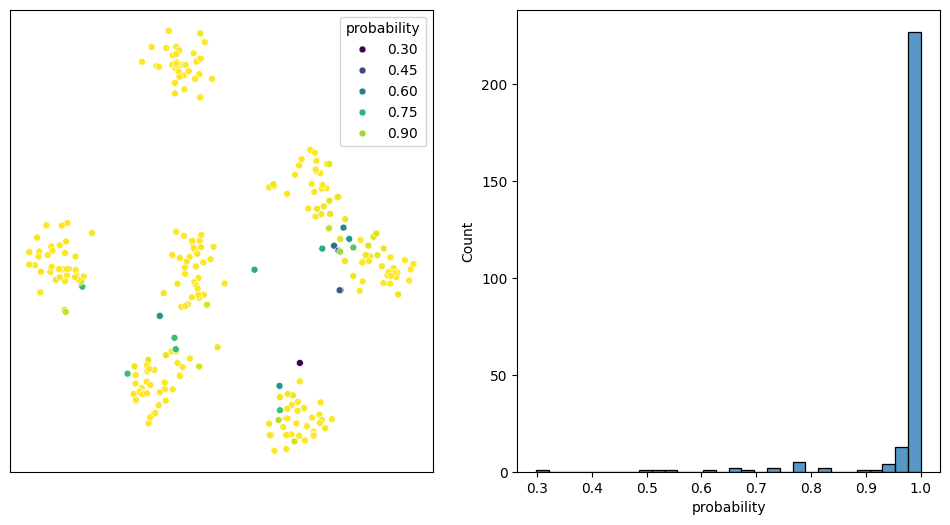

In [8]:
import matplotlib.pyplot as plt
import warnings
from seaborn import histplot
from seaborn import scatterplot

warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

plot_df = train_df.iloc[X_test.index][['x', 'y']].copy()
plot_df['probability'] = np.max(logreg.predict_proba(X=X_test), axis=1)

fig, ax = plt.subplots(ncols=2, figsize=(12, 6))
scatterplot(ax=ax[0], data=plot_df, x='x', y='y', hue='probability', palette='viridis', s=25)
ax[0].set(xlabel=None) 
ax[0].set(ylabel=None)
ax[0].set(xticklabels=[])
ax[0].set(yticklabels=[])
ax[0].tick_params(axis='both', which='both', length=0)
histplot(ax=ax[1], data=plot_df, x='probability', bins=30)
fig.show()

Nice.